# Collective inference with ABC

In [16]:
from sbi.inference import MCABC
import torch
from sbi.utils import BoxUniform
from sbi.inference import simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import sys
sys.path.insert(1,'..')
from simulators import wrapper, WF
import warnings
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.simplefilter('ignore', Warning)

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize



## Starting from individual inference

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

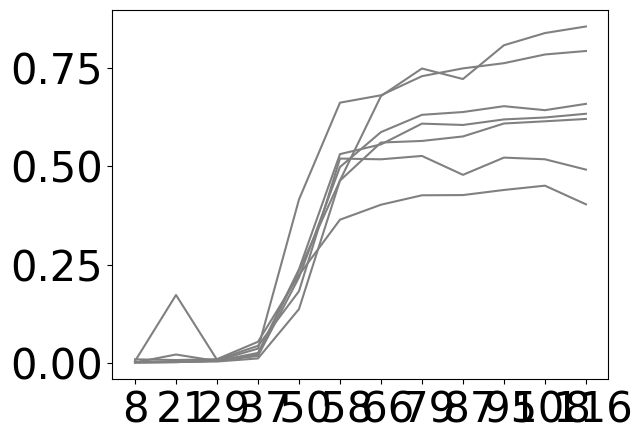

In [88]:
# Define Prior for ABC
prior = BoxUniform(low=torch.tensor([-1.5, -7, -7]), high=torch.tensor([-0.5, -3, -4]))

# Simulator and empirical data
simulator = WF
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)

generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns
X = pd.read_csv('empirical_data/ltr.csv', index_col=0)
log_probs = []
abcs = []

# Quick inference with ABC
# Distance threshold is high because our data is very noisy
for i in range(len(X)):
    x = X.iloc[i,:]
    plt.plot(generation, x, color='grey')
    abc = MCABC(prior=prior, simulator=simulator)
    y = abc(x_o=x, num_simulations=10000, kde=True, eps=0.5)
    log_probs.append(y.log_prob)
    abcs.append(y)

# Collective inference with the collective posterior

In [89]:
from collective_posterior import CollectivePosterior

# Define collective posterior
op = CollectivePosterior(prior, X, posterior_list=log_probs, log_C=1, epsilon=-1000, sample_var=0.05)
# Estimate log(normalizing constant)
op.get_log_C(n_reps=1)

tensor(18.2184)

In [90]:
# sample from collective posterior
samples = op.rejection_sample(100)

Rejection Sampling: 125it [00:01, 83.10it/s]                        


Text(0, 0.5, 'CNV Proportion')

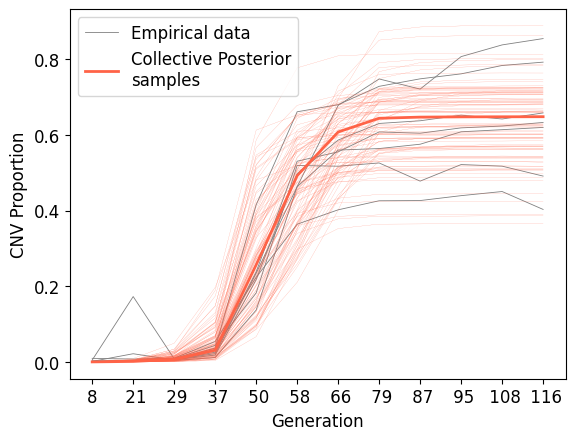

In [91]:
# Posterior predictive checks - plot simulator(samples) against data
change_font(12)
for i in range(len(X)):
    x = X.iloc[i,:]
    plt.plot(generation, x, color='grey', lw=0.6, label = 'Empirical data' if i==0 else '')
    

for i in range(100):
    x_est = WF(samples[i])
    plt.plot(generation, x_est, color='tomato', lw=0.1)

# Highlight sample mean
plt.plot(generation, WF(samples.mean(0)), color='tomato', lw=2, label = 'Collective Posterior\nsamples')
plt.legend(loc='upper left')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')

Predictive checks look great, now let's see the marginal and pairwise posteriors

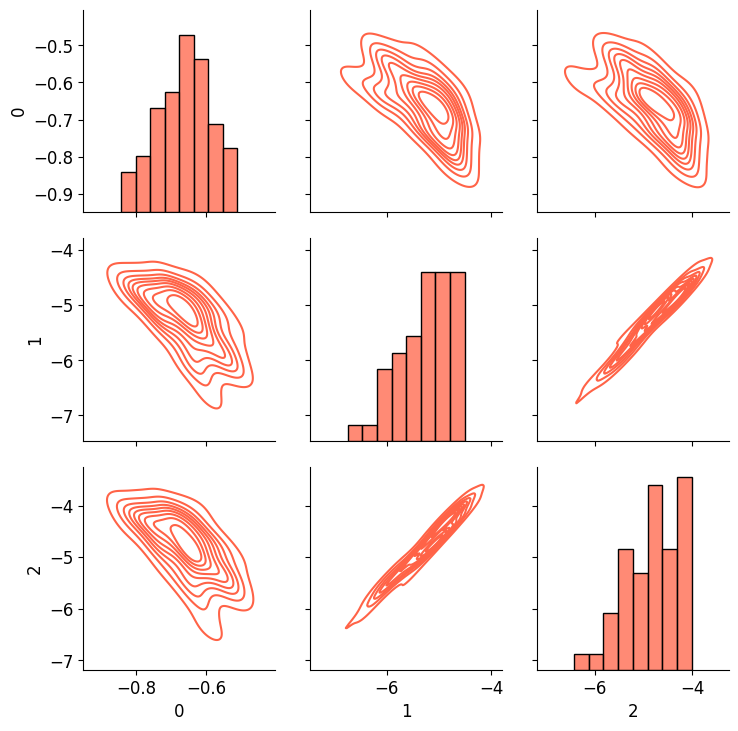

In [92]:
# visualizing with seaborn pairplot

import seaborn as sns
df = pd.DataFrame(samples.numpy())
g = sns.PairGrid(df)
g.map_upper(sns.kdeplot,color='tomato')
g.map_lower(sns.kdeplot,color='tomato')
g.map_diag(sns.histplot,color='tomato')


## Visualizing the collective marginal posteriors

Text(0, 0.5, 'CNV Proportion')

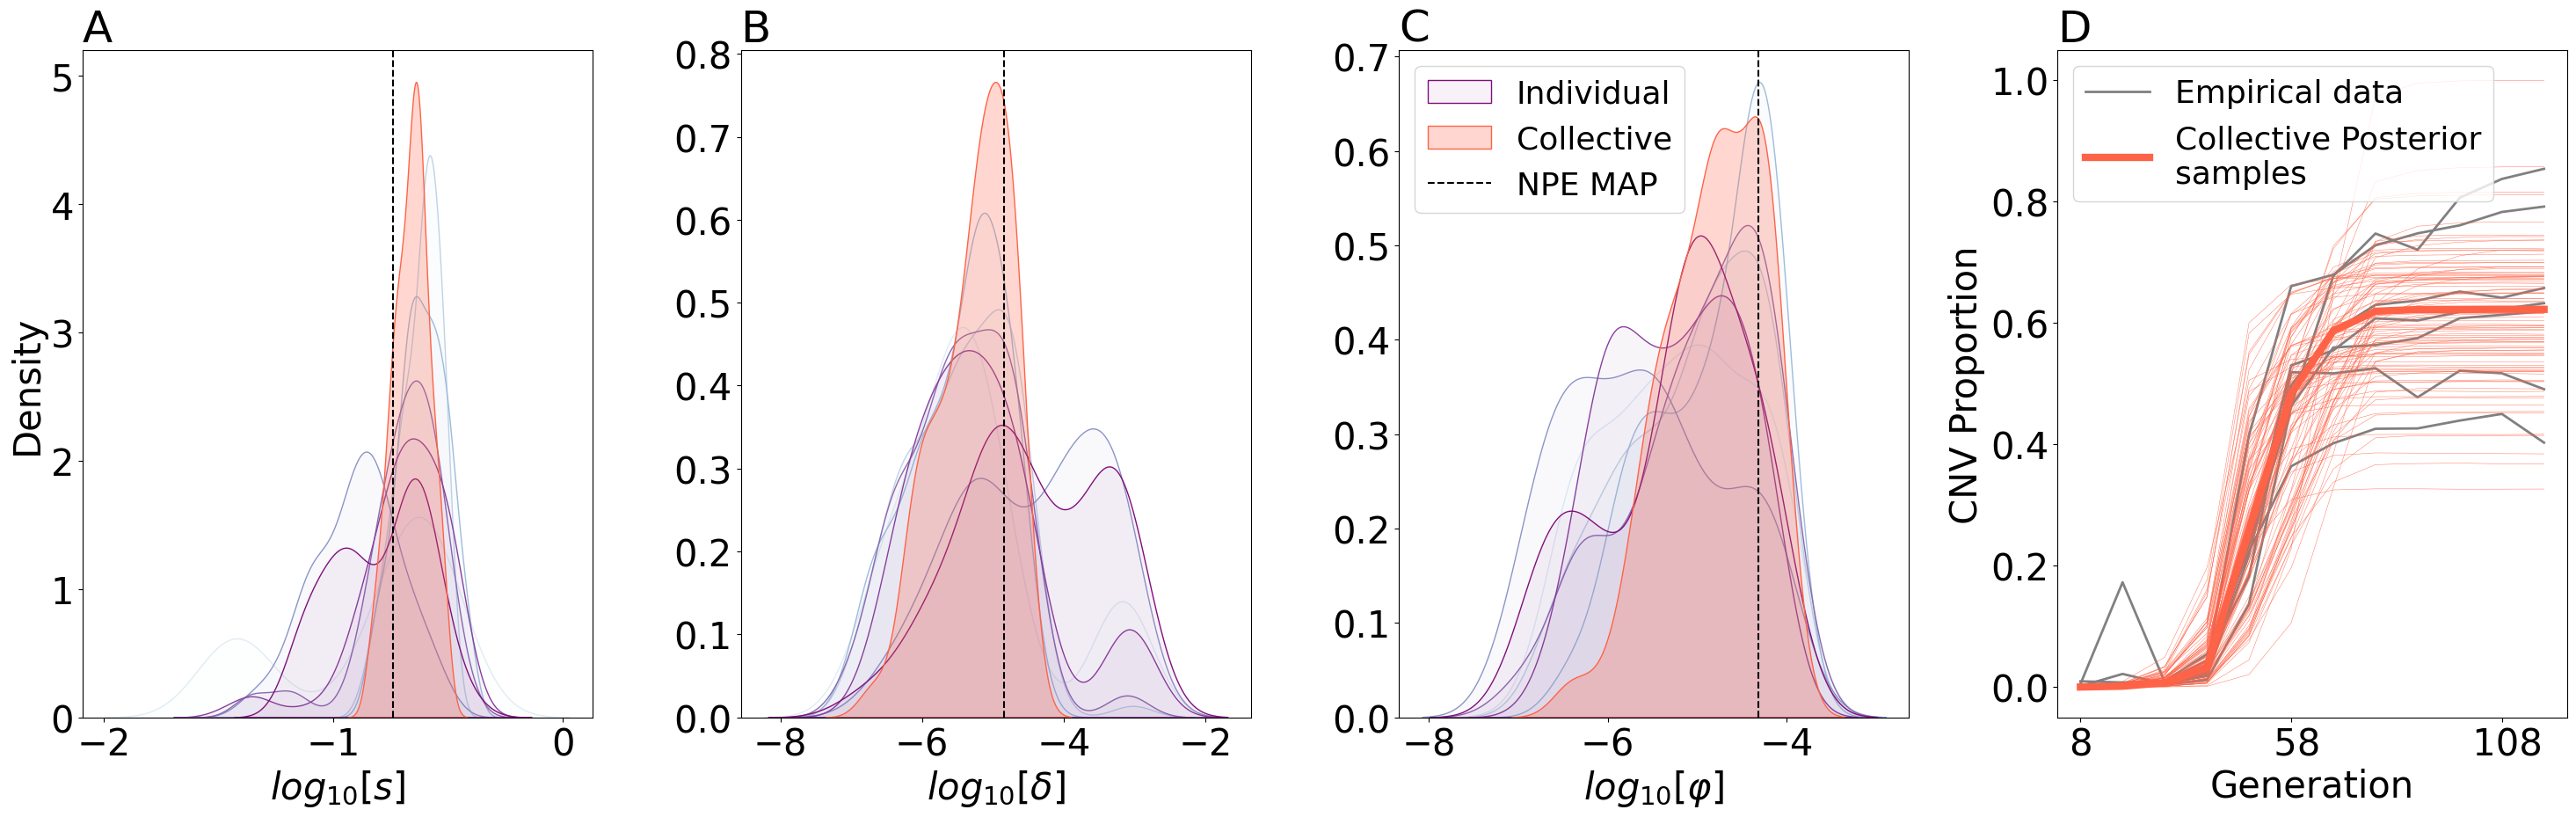

In [94]:
change_font(30)
palette = sns.color_palette("BuPu", 7)
fig, ax = plt.subplots(1,4, tight_layout=True, figsize=(30,10))
ax[0].set_title('A', loc='left')
ax[1].set_title('B', loc='left')
ax[2].set_title('C', loc='left')
ax[3].set_title('D', loc='left')

for i in range(3):
    for j in range(len(abcs)):
        sns.kdeplot(abcs[j].sample((100,))[:,i], color=palette[j], fill=True, alpha=0.05, label='Individual' if i==2 and j==6 else '', ax=ax[i])
    sns.kdeplot(samples[:,i], color='tomato', fill=True, label='Collective' if i==2 else '', ax=ax[i])
ax[0].set_xlabel('$log_{10}[s]$')
ax[1].set_xlabel('$log_{10}[δ]$')
ax[2].set_xlabel('$log_{10}[φ]$')
ax[0].axvline(-0.74, color='k', ls='--')
ax[1].axvline(-4.84, color='k', ls='--')
ax[2].axvline(-4.32, color='k', ls='--', label='NPE MAP')
ax[2].legend(loc='upper left', fontsize=26)
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ticks = ax[3].set_xticks([0,5,10])

for i in range(len(X)):
    x = X.iloc[i,:]
    ax[3].plot(generation, x, color='grey', lw=2, label = 'Empirical data' if i==0 else '')
    

for i in range(100):
    x_est = WF(samples[i])
    ax[3].plot(generation, x_est, color='tomato', lw=0.3)

# Highlight sample mean
ax[3].plot(generation, WF(samples.mean(0)), color='tomato', lw=6, label = 'Collective Posterior\nsamples')
ax[3].legend(loc='upper left', fontsize=26)
ax[3].set_xlabel('Generation')
ax[3].set_ylabel('CNV Proportion')